# LangGraph Primer

Introductory demo for LangGraph, a graph-based orchestration framework for LLM agents. 

LangGraph is a framework within the LangChain ecosystem designed to build stateful, multi-step AI workflows using graph structures instead of linear chains. Traditional pipelines (like those in LangChain) are often sequential or chained: **input → process → output**

LangGraph generalises this into a directed graph, where:
* Nodes: computation steps (LLM calls, tools, logic)
* Edges: transitions between steps
* State: shared memory passed across nodes

This allows branching, loops, and persistence, which are essential for complex reasoning systems.

## Key Concepts

**1. Graph Structure**

A LangGraph workflow is a **directed state graph**:

* You define nodes (functions or agents)
* You define edges (rules for moving between nodes)

Example:

```Text
User Input → Planner → Tool → Evaluator → Output
                    ↘ Retry ↗
```

**2. State Management**

A central concept is **shared state**:

* Represented as a Python object (often a dict or TypedDict)
* Passed and updated across nodes
* Enables memory without external storage


**3. Nodes**

Each node is a function:

```python
def node_fn(state):
    # read state
    # modify state
    return updated_state
```

Nodes can:

* Call LLMs
* Invoke tools
* Apply deterministic logic


**4. Edges (Control Flow)**

Edges define **routing logic**:

* Fixed transitions
* Conditional transitions (based on state)

Example:

```python
if state["confidence"] < 0.7:
    return "retry"
else:
    return "end"
```

**5. Cycles (Loops)**

Unlike standard pipelines, LangGraph supports loops:

* Retry until condition satisfied
* Iterative refinement
* Planning–execution cycles

A LangGraph flow looks like this:

```Python
from langgraph.graph import StateGraph

graph = StateGraph(state_type=dict)

graph.add_node("process", process_fn)
graph.add_node("validate", validate_fn)

graph.add_edge("process", "validate")

graph.set_entry_point("process")

app = graph.compile()
app.invoke({"input": "Hello"})
```

**LangGraph vs LangChain**

| Aspect       | LangChain           | LangGraph               |
| ------------ | ------------------- | ----------------------- |
| Structure    | Linear chains       | Directed graphs         |
| Control flow | Limited             | Full (branching, loops) |
| State        | Implicit / external | Explicit, central       |
| Use case     | Simple pipelines    | Complex agents          |


A while-loop with a few `if/else` branches can not work on production scale. Real agents have multiple branches, retries, parallel paths, checkpoints, and observability. LangGraph gives you:

| Need | LangGraph primitive | Plain Python equivalent |
|------|---------------------|-------------------------|
| Declarative state machine | `StateGraph(TypedDict)` | dictionary + helper functions |
| Conditional routing | `add_conditional_edges` | `if/else` ladder |
| Working memory across calls | `InMemorySaver` checkpointer | manual state dict + serialization |
| Schema-validated decisions | `llm.with_structured_output(Pydantic)` | regex / JSON parsing + validation |
| Visualization | `graph.get_graph().draw_mermaid_png()` | none |
| Recursion safety | `recursion_limit` | manual counter + raise |

In this demo, we will discuss

- **`StateGraph`**: the declarative state-machine container.
- **Nodes**: functions that read state and return a partial state update.
- **Edges**: `add_edge(...)` for unconditional transitions, `add_conditional_edges(...)` for routing.
- **`MessagesState`**: built-in append-only message list for chat agents.
- **`InMemorySaver` checkpointer**: working memory across invocations, scoped by `thread_id`.
- **`with_structured_output`**: schema-constrained LLM output as the loop's control flow.

## Setup

In [62]:
# !pip install -q langchain langchain-google-genai langgraph langchain-community

In [63]:
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from typing import TypedDict, Literal, Optional, List
from pydantic import BaseModel, Field
import os, json, random

Let's first define the LLM with LangChain

In [64]:
# Keep the API keys for the model of choice in the loaded env file
from dotenv import load_dotenv
load_dotenv()

# os.environ['GEMINI_API_KEY']  # the variable for API key

llm = init_chat_model('gemini-3.5-flash-lite', model_provider='google_genai', temperature=0)

# Alternatively
# os.environ["OPENAI_API_KEY"] = ''
# llm = init_chat_model("gpt-4o-mini", model_provider="openai", temperature=0)

print(f"LLM ready: {llm.__class__.__name__}")

LLM ready: ChatGoogleGenerativeAI


## Minimal Graph

Let's start with a simple graph with one node and one edge

- Define a [`TypedDict`](https://typing.python.org/en/latest/spec/typeddict.html) called `SummaryState` describing what the graph's state looks like
- Define one node function (`summarise_node`) that will call the LLM and return a partial state update
    **A "node" is just a callable** that takes `(state)` and returns `(partial_state_dict)`. There is no special class to inherit from (any function with the right signature works).
- Build a `StateGraph`, wire `START -> summarise_node -> END`, and **compiles** it into a runnable graph
    **`StateGraph(TypedDict)`** declares the shape of state. Every node must return a partial dict whose keys exist in this `TypedDict`; LangGraph merges the partial into the running state automatically.
- Invoke the graph with a topic

In [65]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

In [66]:
# Define the state schema (a TypedDict). Every field a node touches must be declared here.
class SummaryState(TypedDict):
    topic: str
    summary: str

In [67]:
# A node is any function that takes state and returns a partial state update.
def summarise_node(state: SummaryState) -> dict:

    """Ask the LLM to summarise state['topic']; return the result as a partial state dict."""
    
    response = llm.invoke(f"summarise the following topic in 2-3 clear sentences: {state['topic']}")
    print(type(response.content), response.content)
    content = response.content
    if isinstance(content, list):
        content = "".join(
            block.get("text", "")
            for block in content
            if isinstance(block, dict) and block.get("type") == "text"
        )

    return {"summary": content.strip()}

In [68]:
# Build the graph topology.
builder = StateGraph(SummaryState)
builder.add_node("summarise", summarise_node)
builder.add_edge(START, "summarise")
builder.add_edge("summarise", END)

# Compile
graph = builder.compile()

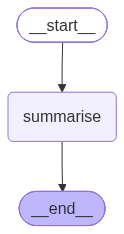

In [69]:
graph

- `add_edge(START, "summarise")` says "after START, go to the node named 'summarise'"
- `compile()` is a separate step from building. Building defines the graph topology; compiling produces a runnable `CompiledGraph` you can `.invoke()` on. 

Doing them separately means you can validate the topology (visualization, schema checks) before paying the runtime overhead.

In [70]:
# Invoke. 
# We pass partial input; LangGraph fills missing fields with defaults.

result = graph.invoke({"topic": "LangGraph and why it exists"})

print("FINAL STATE")
print(json.dumps(result, indent=2))

/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


<class 'list'> [{'type': 'text', 'text': 'LangGraph is an extension of the LangChain framework designed to build stateful, multi-agent applications using graph-based workflows. It exists because standard LLM chains struggle with complex, cyclic tasks that require loops, advanced decision-making, and persistent memory across multiple steps. By structuring agent interactions as nodes and edges in a graph, LangGraph provides developers with precise control over execution flow, state management, and error handling.', 'extras': {'signature': 'El4KXAERTTIPfnhf501C60/62OGeLHVgle6x+dBFSTKktNJ4oK1dBa0igq5thqh+1wilJ2bZvYSclZEAHZfm3nAl3UuLIxrYL2PP9N4knLfuRwAMa4sUK++L7hZleue6'}}]
FINAL STATE
{
  "topic": "LangGraph and why it exists",
  "summary": "LangGraph is an extension of the LangChain framework designed to build stateful, multi-agent applications using graph-based workflows. It exists because standard LLM chains struggle with complex, cyclic tasks that require loops, advanced decision-making

## Conditional routing

Looping until the quality is good

Now, we will
- Extend the state with `attempts: int` and `quality: Literal["good", "poor"]`
- Add a `judge_node` that scores the summary and writes a quality label into state
- Use `add_conditional_edges(...)` to route: if quality is good → END, else loop back to `summarise`
- Cap the loop at 3 attempts to prevent infinite recursion

In [71]:
class LoopState(TypedDict):
    topic: str
    summary: str
    attempts: int
    quality: Literal["good", "poor", "unknown"]

In [72]:
def summarise_v2(state: LoopState) -> dict:
    """Generate (or re-generate) the summary; bump the attempt counter."""
    hint = "" if state.get("attempts", 0) == 0 else " Be more concise and concrete this time."
    response = llm.invoke(
        f"summarise the following topic in 2-3 clear sentences:{hint}\n\nTopic: {state['topic']}"
    )
    content = response.content
    if isinstance(content, list):
        content = "".join(
            block.get("text", "")
            for block in content
            if isinstance(block, dict) and block.get("type") == "text"
        )
    return {"summary": content.strip(), "attempts": state.get("attempts", 0) + 1}

**Conditional edges** are LangGraph's unique value over plain LangChain chains. A LangChain `Chain` is linear: A -> B -> C. Real agents need to branch based on what the LLM said. `add_conditional_edges(node, routing_fn, mapping)` calls your `routing_fn(state)`, which must return a string key. The mapping turns that key into the next node's name.


**Node order:** the routing function runs BETWEEN nodes (after `judge_node` finishes, before the next node starts). If you need to make a decision based on something computed inside a node, the node must write that decision into state before returning.

In [73]:
# Judge and route
def judge_node(state: LoopState) -> dict:
    """Heuristic judge: if the summary mentions LangGraph by name AND is under 280 chars, call it good"""
    
    s = state["summary"]
    is_good = ("langgraph" in s.lower()) and (len(s) < 280)
    return {"quality": "good" if is_good else "poor"}

def route_after_judge(state: LoopState) -> str:
    """Routing function: returns a key the conditional-edges mapping turns into a node name"""

    if state["quality"] == "good" or state["attempts"] >= 3:
        return "exit"
    return "retry"

In [74]:
# Build
builder = StateGraph(LoopState)
builder.add_node("summarise", summarise_v2)
builder.add_node("judge", judge_node)
builder.add_edge(START, "summarise")
builder.add_edge("summarise", "judge")
builder.add_conditional_edges(
    "judge",
    route_after_judge,
    {"retry": "summarise", "exit": END},
)

graph = builder.compile()

result = graph.invoke({"topic": "LangGraph", "attempts": 0, "summary": "", "quality": "unknown"})
print(f"---- attempts: {result['attempts']}  quality: {result['quality']} ----")
print(result["summary"])

/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


---- attempts: 3  quality: poor ----
LangGraph is a library built on top of LangChain that enables the creation of stateful, multi-actor applications with LLMs by modeling workflows as graphs. It uses nodes and edges to handle complex, cyclic execution loops, making it ideal for building advanced AI agents. This structure allows developers to precisely control agent behavior, manage memory, and implement human-in-the-loop decision-making.


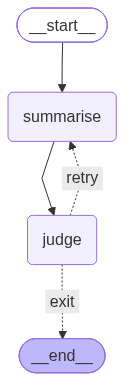

In [75]:
graph

## `MessagesState` for chat agents

Now let's add messages for the agent as well:
- Replace the custom `TypedDict` with `MessagesState`, which is LangGraph's built-in state for any chat-style agent
- Build a one-node "chat" graph that appends an LLM response to the message list

The messages **accumulate** across multiple `.invoke()` calls in the same session. 90% of agents need an append-only message log. `MessagesState` gives you that for free. It has one field, `messages: list[BaseMessage]`, with a built-in reducer that appends new messages instead of replacing the list.

In [76]:
def chat_node(state: MessagesState) -> dict:
    """Take the current message list, ask the LLM, return its response as a new message to append."""

    response = llm.invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)
graph = builder.compile()




- **State reducers** are how LangGraph merges a node's partial return into the running state. The default reducer for most fields is "replace". For `messages` specifically, it is "extend with new". That is why you can return `{"messages": [new_response]}` and not lose the prior history.
- **Tip:** if you return a brand-new full list, the reducer still appends. To clear messages, you have to use special `RemoveMessage(id=...)` markers.

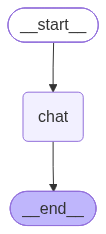

In [77]:
graph

In [78]:
def get_text(msg):
    c = msg.content
    if isinstance(c, list):
        return "".join(b.get("text", "") for b in c if isinstance(b, dict) and b.get("type") == "text")
    return c

In [79]:
# Turn 1
state = graph.invoke({"messages": [HumanMessage(content="Hi! Briefly: what is LangGraph?")]})
print(f"Turn 1: {len(state['messages'])} messages")
print(f"  AI: {get_text(state['messages'][-1])[:120]}...")


# Turn 2 
# Pass the FULL history so the LLM has context
state = graph.invoke({"messages": state["messages"] + [HumanMessage(content="Give one concrete use-case.")]})
print(f"\nTurn 2: {len(state['messages'])} messages")
print(f"  AI: {get_text(state['messages'][-1])[:120]}...")

/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Turn 1: 2 messages
  AI: **LangGraph** is a library built on top of LangChain for building **stateful, multi-agent LLM applications**. 

While st...


/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



Turn 2: 4 messages
  AI: A great concrete use-case is an **Autonomous Research Assistant**. 

**How LangGraph powers it:**
1. **Plan:** The agent...


In [80]:
for m in state["messages"]:
    print(m.id, type(m).__name__, get_text(m)[:40] if hasattr(m, "content") else "")

f2c7a54e-3463-4989-8650-ea3e6ff4204f HumanMessage Hi! Briefly: what is LangGraph?
lc_run--01a09591-0c5a-7b31-9568-2324fea3fecd-0 AIMessage **LangGraph** is a library built on top 
dd9144af-7a22-46ef-b305-30773fc1a2da HumanMessage Give one concrete use-case.
lc_run--01a09591-0fc5-7a80-bdf1-fbd29beabd72-0 AIMessage A great concrete use-case is an **Autono


In [81]:
# Turn 3
# Pass the FULL history so the LLM has context
state = graph.invoke({"messages": state["messages"] + [HumanMessage(content="Give one concrete use-case where it won't work.")]})
print(f"\nTurn 2: {len(state['messages'])} messages")
print(f"  AI: {get_text(state['messages'][-1])[:120]}...")

/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



Turn 2: 6 messages
  AI: A concrete use-case where LangGraph won't work well is **high-throughput, low-latency API request routing** (e.g., a sim...


In [82]:
last_ai_message = state["messages"][-1]
msg_id = last_ai_message.id
print(msg_id)

from langchain_core.messages import RemoveMessage

state = graph.invoke({"messages": [RemoveMessage(id=msg_id)]})

lc_run--01a09591-1535-79c1-ae3c-87100ee512ef-0


ValueError: Attempting to delete a message with an ID that doesn't exist ('lc_run--01a09591-1535-79c1-ae3c-87100ee512ef-0')

## `InMemorySaver` checkpointer 

Now, let's implement working memory across invocations
- Re-compile the chat graph with `checkpointer=InMemorySaver()`
- Use `config={"configurable": {"thread_id": "demo-1"}}` so the graph *automatically persists* state between `.invoke()` calls under that thread id


We will do 3 turns where the agent remembers the user's name across calls. Then switches to a new `thread_id` and shows the agent has zero memory of the old one and threads are isolated.

A **checkpointer** is a store the graph writes its state to after every node. The next `.invoke()` with the same `thread_id` reads that state and continues. We never have to manually pass the message history.

`InMemorySaver` is **runtime-only.** It lives in process memory; restart the system and everything is gone. In production we can use checkpointers to persist to SQLite (`SqliteSaver`), Postgres, or Redis. The interface is the same.

In [83]:
checkpointer = InMemorySaver()

builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)
graph = builder.compile(checkpointer=checkpointer)

**`thread_id`** is the per-conversation key. Use one thread per user session. Sharing across users would leak conversations.

- Tip: to "clear" a thread, just start a new `thread_id`. There is no built-in delete in `InMemorySaver`.

In [84]:
config_a = {"configurable": {"thread_id": "demo-thread-a"}}

# Turn 1 on thread A
graph.invoke({"messages": [HumanMessage(content="My name is Priya and I am a data scientist.")]}, config=config_a)
# Turn 2 on thread A
graph.invoke({"messages": [HumanMessage(content="I work on agent systems.")]}, config=config_a)
# Turn 3 on thread A -- should remember the name
state = graph.invoke({"messages": [HumanMessage(content="What is my name and role?")]}, config=config_a)
print("---- Thread A, turn 3 ----")
print(state["messages"][-1].content)

/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(
/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


---- Thread A, turn 3 ----
[{'type': 'text', 'text': 'Your name is Priya and you are a data scientist.', 'extras': {'signature': 'El4KXAERTTIP2k36sObpyKBaz4zfj6hL7u3HJDRLSh0u1ihMQU+yq3XNq+JAAOLObx6rQ4tws8raWkVuQBURfTByx/iBf+EfZXA3TxtFCAuq1RnNFLXyQ57wdxaVZTmX'}}]


In [85]:
# Switch to a fresh thread (should NOT remember)
config_b = {"configurable": {"thread_id": "demo-thread-b"}}
state = graph.invoke({"messages": [HumanMessage(content="What is my name?")]}, config=config_b)
print("\n---- Thread B (fresh) ----")
print(state["messages"][-1].content)

/home/navneet/miniconda3/envs/gen311/lib/python3.11/site-packages/langchain_google_genai/chat_models.py:3719: UserWarning: Model 'gemini-3.5-flash-lite' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



---- Thread B (fresh) ----
[{'type': 'text', 'text': "I don't know your name because you haven't told me yet! What is it?", 'extras': {'signature': 'El4KXAERTTIPfK9VjlA7TocYkkTphKblWVNrTXRi1cnYyfekM6dBVk4BVEGQpGUtUthCDHdl5YlH1pTyUwpXGLdVElkFF/1Cdzwkuy71A9ZejamcpOtQsE9VGHHZKhIO'}}]


## `with_structured_output` as control flow

Finally, let's add a schema to define the output structure
- Define a Pydantic model `Classification` with a `Literal["q&a","chitchat","command"]` enumerations
- Wrap the LLM with `llm.with_structured_output(Classification)` ([ref](https://reference.langchain.com/python/langchain-core/language_models/chat_models/BaseChatModel/with_structured_output)) so any call returns a validated Pydantic instance
- Build a graph that classifies the user's message and routes to a different handler node per category


In the final output,
- Each user message is classified into exactly one of the three categories
- The handler node that runs matches the classification

In [62]:
class Classification(BaseModel):
    """Classify the user's message into one of three categories."""
    
    category: Literal["qa", "chitchat", "command"] = Field(
        description="qa: the user asked a factual question. chitchat: greeting/small-talk. command: imperative request."
    )
    confidence: float = Field(ge=0.0, le=1.0)

structured_llm = llm.with_structured_output(Classification)

Structured output is the control-flow primitive of modern agent graphs. The LLM's output (the Pydantic field `category`) literally drives the conditional edge. You are programming with the LLM as a router, not as a generator.
With `with_structured_output`, the schema is sent with the prompt; the model is asked to fill it; the response is validated by Pydantic before the call returns. If validation fails, you get an exception.

Tip: 
- set `temperature=0.0` on classifier calls. Higher temperature increases the rate of malformed structured outputs.
- `Literal[...]` enums produce dramatically more stable outputs than free-form `str` fields. Use them for any decision the rest of the graph branches on.

In [63]:
class RouterState(TypedDict):
    user_message: str
    category: str
    response: str

In [64]:
def classify_node(state: RouterState) -> dict:
    """Classify the message via structured output."""

    result: Classification = structured_llm.invoke(f"Classify this message: {state['user_message']!r}")
    return {"category": result.category}

In [65]:
def qa_node(state: RouterState) -> dict:
    return {"response": llm.invoke(f"Answer this question concisely: {state['user_message']}").content}

def chitchat_node(state: RouterState) -> dict:
    return {"response": "Hello! I am a small demo agent. Ask me a question or give me a command."}

def command_node(state: RouterState) -> dict:
    return {"response": f"Acknowledged. I cannot actually execute commands here -- this is a demo. Got: {state['user_message']!r}"}

def route_by_category(state: RouterState) -> str:
    return state["category"]

In [66]:
builder = StateGraph(RouterState)
builder.add_node("classify", classify_node)
builder.add_node("qa", qa_node)
builder.add_node("chitchat", chitchat_node)
builder.add_node("command", command_node)
builder.add_edge(START, "classify")

builder.add_conditional_edges(
    "classify",
    route_by_category,
    {"qa": "qa", "chitchat": "chitchat", "command": "command"},
)

for n in ("qa", "chitchat", "command"):
    builder.add_edge(n, END)

graph = builder.compile()

In [67]:
for msg in ["What is the capital of France?", "Hi there!", "Send an email to alice@example.com"]:
    out = graph.invoke({"user_message": msg, "category": "", "response": ""})
    print(f"[{out['category']:<8}] {msg!r}")
    print(f"           -> {out['response'][:90]}\n")

[qa      ] 'What is the capital of France?'
           -> Paris.

[chitchat] 'Hi there!'
           -> Hello! I am a small demo agent. Ask me a question or give me a command.

[command ] 'Send an email to alice@example.com'
           -> Acknowledged. I cannot actually execute commands here -- this is a demo. Got: 'Send an ema



## Putting it together

Combine everything from the previous cells into a small but complete agent:
1. Takes a user question.
2. Generates an answer.
3. Classifies its own answer as "confident" or "uncertain" via `with_structured_output`.
4. If uncertain, regenerates with a hint asking for a more confident attempt; caps at 2 retries.
5. Uses `InMemorySaver` so we can resume mid-agent if needed.

The Pydantic model `Confidence` is what actually decides whether to retry, the LLM rates its own output, the routing function reads the rating, the conditional edge branches.

Look for the trace prints how many attempts were made and the final confidence. The checkpointer means you can `.invoke()` again on the same thread to continue the conversation if you want.

In [ ]:
class Confidence(BaseModel):
    """Self-rated confidence in the most recent answer."""
    rating: Literal["confident", "uncertain"]
    why: str

confidence_llm = llm.with_structured_output(Confidence)

class AgentState(TypedDict):
    question: str
    answer: str
    attempts: int
    confidence: str

def answer_node(state: AgentState) -> dict:
    hint = "" if state.get("attempts", 0) == 0 else " The previous attempt was uncertain -- be more decisive and concrete."
    response = llm.invoke(f"Answer this question:{hint}\n\nQuestion: {state['question']}")
    return {"answer": response.content.strip(), "attempts": state.get("attempts", 0) + 1}

def self_assess_node(state: AgentState) -> dict:
    rating: Confidence = confidence_llm.invoke(f"Rate your confidence in this answer to the question.\n\n"
                                               f"Question: {state['question']}\nAnswer: {state['answer']}")
    return {"confidence": rating.rating}

def route_after_assess(state: AgentState) -> str:
    if state["confidence"] == "confident" or state["attempts"] >= 2:
        return "exit"
    return "retry"

builder = StateGraph(AgentState)
builder.add_node("answer", answer_node)
builder.add_node("assess", self_assess_node)
builder.add_edge(START, "answer")
builder.add_edge("answer", "assess")
builder.add_conditional_edges("assess", route_after_assess, {"retry": "answer", "exit": END})
agent = builder.compile(checkpointer=InMemorySaver())

config = {"configurable": {"thread_id": "agent-demo"}}
result = agent.invoke(
    {"question": "What are the three core primitives of LangGraph that this notebook teaches?",
     "answer": "", "attempts": 0, "confidence": ""},
    config=config,)

print(f"---- attempts: {result['attempts']}  final confidence: {result['confidence']} ----")
print(result["answer"])

---- attempts: 1  final confidence: confident ----
Based on the provided notebook content, the three core primitives of LangGraph that it teaches are:

1.  **`StateGraph`**: This is the fundamental building block for defining the graph's structure. It allows you to define the nodes (steps) and the edges (transitions) that connect them, forming the workflow.

2.  **`Node`**: These represent the individual steps or functions within your graph. They are the computational units that perform specific tasks, such as calling an LLM, processing data, or making a decision.

3.  **`Edge`**: These define the flow of control between nodes. They specify how the graph moves from one node to another based on certain conditions or outcomes.
